# Construcción de una capa de detección basada en PLM

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/TFG_Posdata/datasets/dataset_final.csv'

Mounted at /content/drive


In [ ]:
import torch
import transformers
import pandas as pd
import numpy as np
import sklearn

df = pd.read_csv(DATASET_PATH)
assert df['text'].notna().all(), 'La columna text contiene valores nulos'
assert df['label'].notna().all(), 'La columna label contiene valores nulos'

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

X = df['text']
y = (df['label'] == 'spam').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({'train': train_dataset, 'test': test_dataset})

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(input):
  return tokenizer(input['text'], padding='max_length', truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4603 [00:00<?, ? examples/s]

Map:   0%|          | 0/1151 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    return {
        'f1': f1_score(labels, preds, average='weighted'),
        'accuracy': accuracy_score(labels, preds)
    }

training_args = TrainingArguments(
   output_dir='/content/drive/MyDrive/TFG_Posdata/models/distilbert_v1',
   num_train_epochs=3,
   per_device_train_batch_size=16,
   learning_rate=2e-5,
   weight_decay=0.01,
   eval_strategy='epoch',
   save_strategy='epoch',
   load_best_model_at_end=True,
   metric_for_best_model='f1'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.049999,0.986932,0.986968
2,0.034563,0.055088,0.988653,0.988705
3,0.034563,0.060871,0.988631,0.988705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=864, training_loss=0.02500373787350125, metrics={'train_runtime': 249.9392, 'train_samples_per_second': 55.249, 'train_steps_per_second': 3.457, 'total_flos': 457310577010176.0, 'train_loss': 0.02500373787350125, 'epoch': 3.0})

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       940
           1       0.98      0.96      0.97       211

    accuracy                           0.99      1151
   macro avg       0.99      0.98      0.98      1151
weighted avg       0.99      0.99      0.99      1151



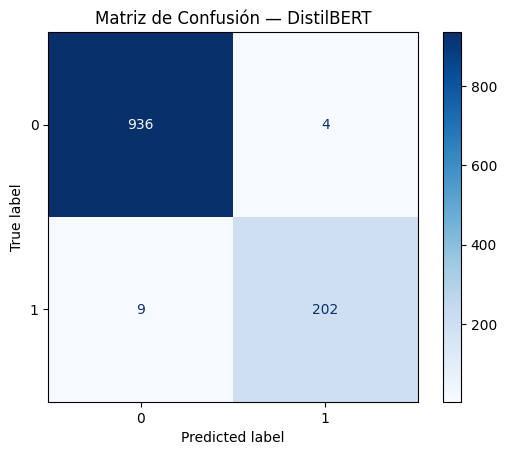

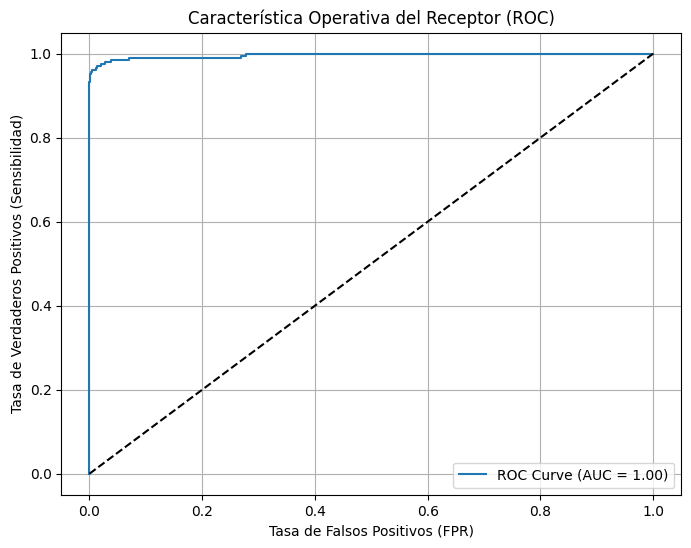

Mejor umbral: 0.9365
Mejor F1-Score: 0.9734


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score

predictions = trainer.predict(tokenized_dataset['test'])

y_pred = np.argmax(predictions.predictions, axis=1)
y_test = predictions.label_ids

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión — DistilBERT")
plt.show()

y_scores = softmax(predictions.predictions, axis=1)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Característica Operativa del Receptor (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

f1_scores = []
for th in thresholds:
    y_pred_th = (y_scores >= th).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_th))

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1 = f1_scores[best_f1_index]

print(f'Mejor umbral: {best_threshold:.4f}')
print(f'Mejor F1-Score: {best_f1:.4f}')




              precision    recall  f1-score   support

           0       0.99      1.00      0.99       940
           1       1.00      0.95      0.97       211

    accuracy                           0.99      1151
   macro avg       0.99      0.98      0.98      1151
weighted avg       0.99      0.99      0.99      1151



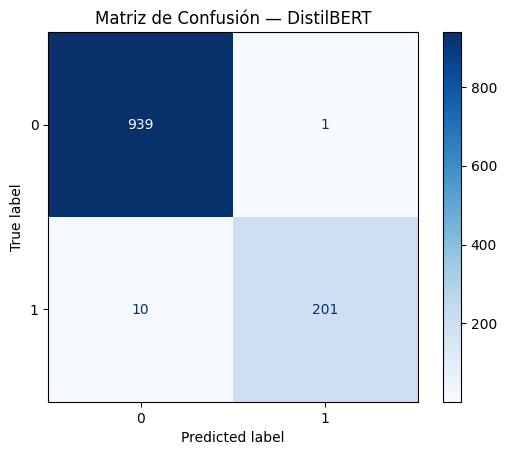

In [ ]:
y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión — DistilBERT")
plt.show()
#Es mejor el umbral anterior, porque genera menos falsos negativos

best_threshold = 0.5


In [ ]:
import joblib
import json

from google.colab import drive
drive.mount('/content/drive')
ruta_carpeta = '/content/drive/MyDrive/TFG_Posdata/models/distilbert_v1/'

trainer.save_model(ruta_carpeta)
tokenizer.save_pretrained(ruta_carpeta)
print("Modelo y tokenizer guardados con éxito")

nombre_config = 'own_config.json'
config = {
    "threshold": best_threshold,
    "base_model": "distilbert-base-multilingual-cased",
    "model_version": "distilbert_v1"
}
with open(ruta_carpeta + nombre_config, 'w') as f:
    json.dump(config, f)
print("Configuración guardada con éxito")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo y tokenizer guardados con éxito
Configuración guardada con éxito


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

ruta = '/content/drive/MyDrive/TFG_Posdata/models/distilbert_v1/'
model = AutoModelForSequenceClassification.from_pretrained(ruta)
tokenizer = AutoTokenizer.from_pretrained(ruta)
model.eval()

dummy_input = tokenizer("dummy text", return_tensors="pt",
                         padding='max_length', truncation=True, max_length=128)

torch.onnx.export(
    model,
    (dummy_input['input_ids'], dummy_input['attention_mask']),
    ruta + 'model.onnx',
    input_names=['input_ids', 'attention_mask'],
    output_names=['logits'],
    dynamic_axes={
        'input_ids': {0: 'batch_size'},
        'attention_mask': {0: 'batch_size'}
    },
    opset_version=14
)
print("Exportado correctamente")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_13731/378937469.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0325 19:17:49.633000 13731 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0325 19:17:53.603000 13731 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1,

[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/no_previous_version.h:26: adapt: Assertion `

Applied 29 of general pattern rewrite rules.
Exportado correctamente
